# 🎬 EDA on Top 10,000 IMDb Movies — Beginner Friendly

This notebook explores a dataset of the top 10,000 movies on IMDb.
We will go step by step, in simple phases, so it's easy to follow even if you're new to data analysis.

**Phases covered:**
1. Load the data
2. Understand the data
3. Check data quality
4. Clean the data
5. Explore single columns (Univariate)
6. Explore relationships between columns (Bivariate)
7. Look at correlations
8. Look for outliers
9. Create a few new useful columns
10. Final summary


## Phase 1: Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set_style("whitegrid")


In [2]:
df = pd.read_csv("Top_10000_Movies_IMD.csv")
df.head()


,ID,Movie Name,Rating,Runtime,Genre,Metascore,Plot,Directors,Stars,Votes,Gross,Link
0,1,The Shawshank Redemption,9.3,142 min,Drama,82.0,"Over the course of several years, two convicts...","['Frank Darabont', 'Tim Robbins', 'Morgan Free...","['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...",2752419,28341469,https://www.imdb.com/title/tt0111161/
1,2,The Godfather,9.2,175 min,"Crime, Drama",100.0,"Don Vito Corleone, head of a mafia family, dec...","['Francis Ford Coppola', 'Marlon Brando', 'Al ...","['Marlon Brando', 'Al Pacino', 'James Caan', '...",1914751,134966411,https://www.imdb.com/title/tt0068646/
2,3,Ramayana: The Legend of Prince Rama,9.2,135 min,"Animation, Action, Adventure",NaN,An anime adaptation of the Hindu epic the Rama...,"['Ram Mohan', 'Yûgô Sakô', 'Koichi Saski', 'Ar...","['Yûgô Sakô', 'Koichi Saski', 'Arun Govil', 'N...",10108,10108,https://www.imdb.com/title/tt0259534/
3,4,The Chaos Class,9.2,87 min,"Comedy, Drama",NaN,"Lazy, uneducated students share a very close b...","['Ertem Egilmez', 'Kemal Sunal', 'Münir Özkul'...","['Kemal Sunal', 'Münir Özkul', 'Halit Akçatepe...",41785,41785,https://www.imdb.com/title/tt0252487/
4,5,Daman,9.1,121 min,"Adventure, Drama",NaN,"The film is set in 2015. Sid, is a young docto...","['Lenka Debiprasad', 'Vishal Mourya', 'Karan K...","['Vishal Mourya', 'Karan Kandhapan', 'Babushan...",13303,13303,https://www.imdb.com/title/tt17592606/


**Insight:** We loaded the dataset. Each row is one movie, with columns like Rating, Genre, Runtime, Votes, and Gross earnings.

## Phase 2: Understand the Data

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 9999
Number of columns: 12


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          9999 non-null   int64  
 1   Movie Name  9999 non-null   str    
 2   Rating      9999 non-null   float64
 3   Runtime     9999 non-null   str    
 4   Genre       9999 non-null   str    
 5   Metascore   7992 non-null   float64
 6   Plot        9999 non-null   str    
 7   Directors   9999 non-null   str    
 8   Stars       9999 non-null   str    
 9   Votes       9999 non-null   int64  
 10  Gross       9999 non-null   int64  
 11  Link        9999 non-null   str    
dtypes: float64(2), int64(3), str(7)
memory usage: 937.5 KB


**Insight:** Most columns look fine, but `Runtime` is text (like `142 min`) instead of a number, and `Metascore` seems to have missing values.

In [5]:
df.describe()


,ID,Rating,Metascore,Votes,Gross
count,9999.000000,9999.000000,7992.000000,9.999000e+03,9.999000e+03
mean,5000.000000,6.698620,58.749625,9.127103e+04,2.874067e+07
std,2886.607005,0.852755,17.472420,1.684508e+05,5.971933e+07
min,1.000000,4.600000,7.000000,1.000100e+04,7.000000e+00
25%,2500.500000,6.100000,46.000000,1.678500e+04,3.654100e+04
50%,5000.000000,6.700000,59.000000,3.391200e+04,4.244155e+06
75%,7499.500000,7.300000,71.000000,8.965600e+04,3.306295e+07
max,9999.000000,9.300000,100.000000,2.752419e+06,9.366622e+08


**Insight:** `Rating` values range roughly between 0 and 10, as expected. `Votes` and `Gross` have very large maximum values compared to their average — this hints at a few very popular/big movies in the data.

## Phase 3: Check Data Quality

### 3.1 Missing Values

In [6]:
df.isnull().sum()


ID               0
Movie Name       0
Rating           0
Runtime          0
Genre            0
Metascore     2007
Plot             0
Directors        0
Stars            0
Votes            0
Gross            0
Link             0
dtype: int64

**Insight:** Only the `Metascore` column has missing values. About 2,000 movies don't have a Metascore.

### 3.2 Duplicate Rows

In [7]:
df.duplicated().sum()


np.int64(0)

**Insight:** There are no duplicate rows, so the dataset is clean in that respect.

## Phase 4: Clean the Data

### 4.1 Fix the `Runtime` Column (Text → Number)

In [8]:
df['Runtime'] = df['Runtime'].str.replace(' min', '', regex=False).astype(int)
df[['Movie Name', 'Runtime']].head()


,Movie Name,Runtime
0,The Shawshank Redemption,142
1,The Godfather,175
2,Ramayana: The Legend of Prince Rama,135
3,The Chaos Class,87
4,Daman,121


**Insight:** `Runtime` is now a number (in minutes), so we can use it in charts and calculations.

### 4.2 Fill Missing `Metascore` Values

In [9]:
df['Metascore'] = df['Metascore'].fillna(df['Metascore'].median())
df['Metascore'].isnull().sum()


np.int64(0)

**Insight:** Missing Metascore values were filled with the median (middle) value, so we no longer lose those rows in our analysis.

### 4.3 Simplify the `Genre` Column

In [10]:
df['Main Genre'] = df['Genre'].apply(lambda x: x.split(',')[0])
df[['Genre', 'Main Genre']].head()


,Genre,Main Genre
0,Drama,Drama
1,"Crime, Drama",Crime
2,"Animation, Action, Adventure",Animation
3,"Comedy, Drama",Comedy
4,"Adventure, Drama",Adventure


**Insight:** Movies can have multiple genres (e.g. `Crime, Drama`). We created a simpler `Main Genre` column using just the first genre listed, which makes grouping and charting much easier.

## Phase 5: Explore Single Columns (Univariate Analysis)

### 5.1 Rating Distribution

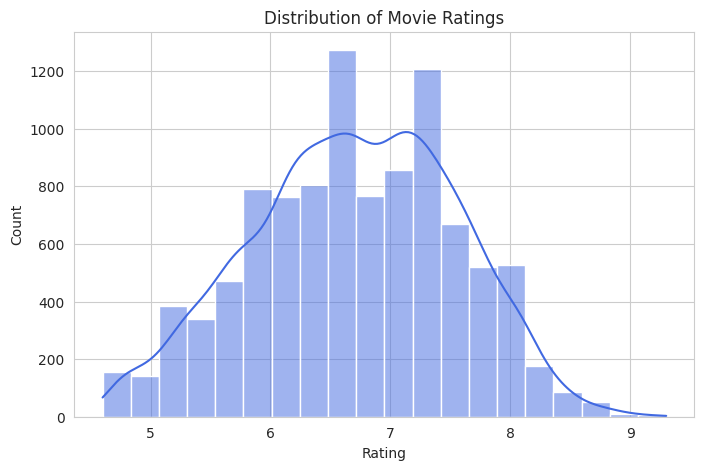

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Rating'], bins=20, kde=True, color='royalblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.show()


**Insight:** Most movies have ratings between 7 and 8.5. This makes sense because this dataset only contains the *top* movies on IMDb.

### 5.2 Runtime Distribution

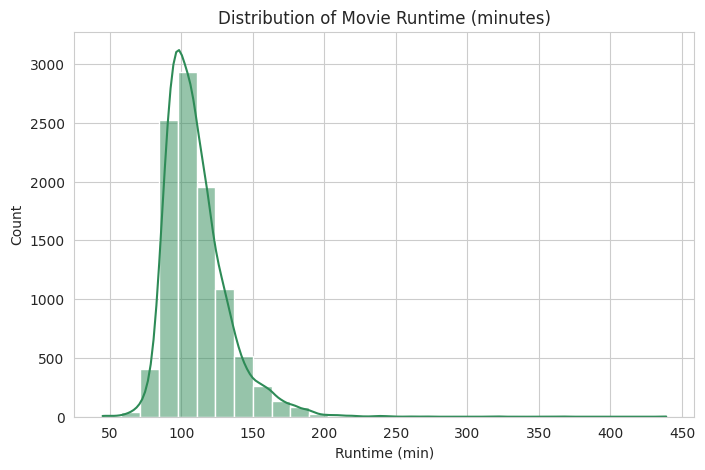

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Runtime'], bins=30, kde=True, color='seagreen')
plt.title('Distribution of Movie Runtime (minutes)')
plt.xlabel('Runtime (min)')
plt.show()


**Insight:** Most movies run between 90 and 150 minutes, which matches the typical length of feature films.

### 5.3 Most Common Genres

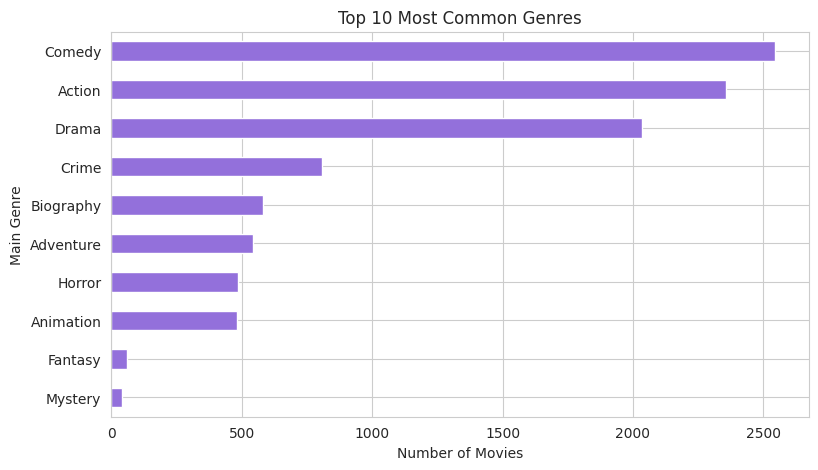

In [13]:
plt.figure(figsize=(9, 5))
df['Main Genre'].value_counts().head(10).plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Number of Movies')
plt.gca().invert_yaxis()
plt.show()


**Insight:** Drama is by far the most common genre, followed by Comedy and Action.

## Phase 6: Explore Relationships Between Columns (Bivariate Analysis)

### 6.1 Rating vs Votes

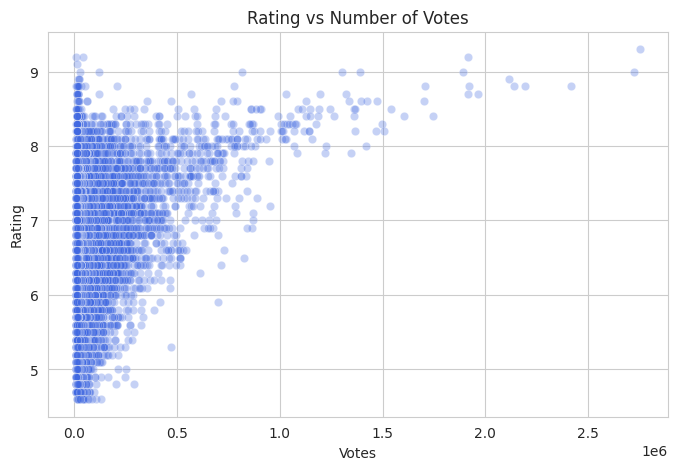

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Votes', y='Rating', alpha=0.3, color='royalblue')
plt.title('Rating vs Number of Votes')
plt.xlabel('Votes')
plt.ylabel('Rating')
plt.show()


**Insight:** Movies with more votes tend to have slightly higher ratings, but the relationship isn't very strong — some highly-voted movies still have lower ratings.

### 6.2 Rating by Genre

/tmp/ipykernel_474/4288745592.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Main Genre', y='Rating', palette='Set2')


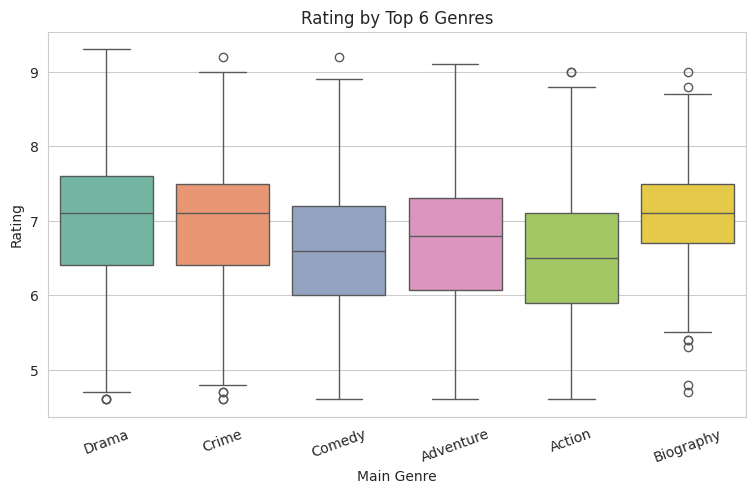

In [15]:
top_genres = df['Main Genre'].value_counts().head(6).index
subset = df[df['Main Genre'].isin(top_genres)]

plt.figure(figsize=(9, 5))
sns.boxplot(data=subset, x='Main Genre', y='Rating', palette='Set2')
plt.title('Rating by Top 6 Genres')
plt.xticks(rotation=20)
plt.show()


**Insight:** Average ratings are fairly similar across genres, but Drama and Animation tend to score slightly higher.

### 6.3 Runtime vs Rating

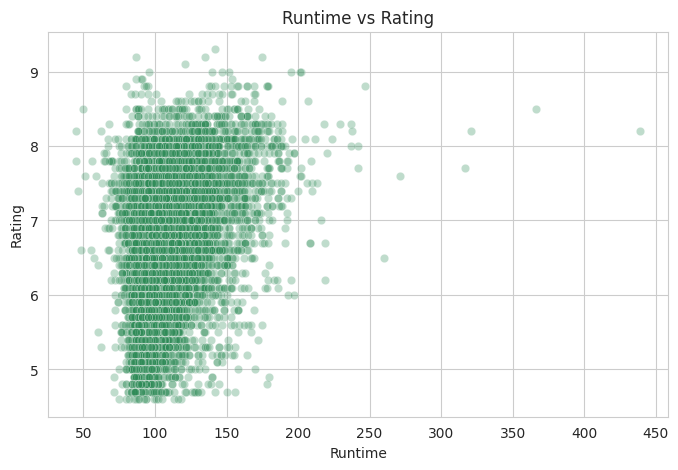

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Runtime', y='Rating', alpha=0.3, color='seagreen')
plt.title('Runtime vs Rating')
plt.show()


**Insight:** There's no strong pattern — longer movies aren't necessarily rated higher or lower.

## Phase 7: Correlation Between Numeric Columns

In [17]:
numeric_cols = ['Rating', 'Runtime', 'Metascore', 'Votes', 'Gross']
correlation = df[numeric_cols].corr()
correlation


,Rating,Runtime,Metascore,Votes,Gross
Rating,1.000000,0.345162,0.624366,0.307727,0.064945
Runtime,0.345162,1.000000,0.182595,0.197374,0.124496
Metascore,0.624366,0.182595,1.000000,0.200814,0.027947
Votes,0.307727,0.197374,0.200814,1.000000,0.632156
Gross,0.064945,0.124496,0.027947,0.632156,1.000000


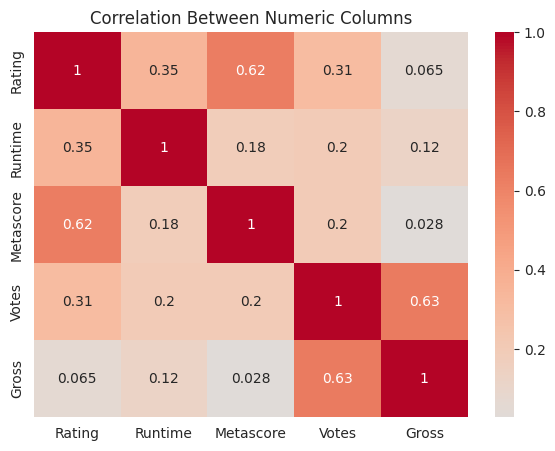

In [18]:
plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Numeric Columns')
plt.show()


**Insight:** `Votes` and `Gross` are strongly related — more popular movies tend to earn more money. `Rating` doesn't correlate strongly with anything else, meaning rating depends on more than just these numbers (like genre, director, or story quality).

## Phase 8: Look for Outliers

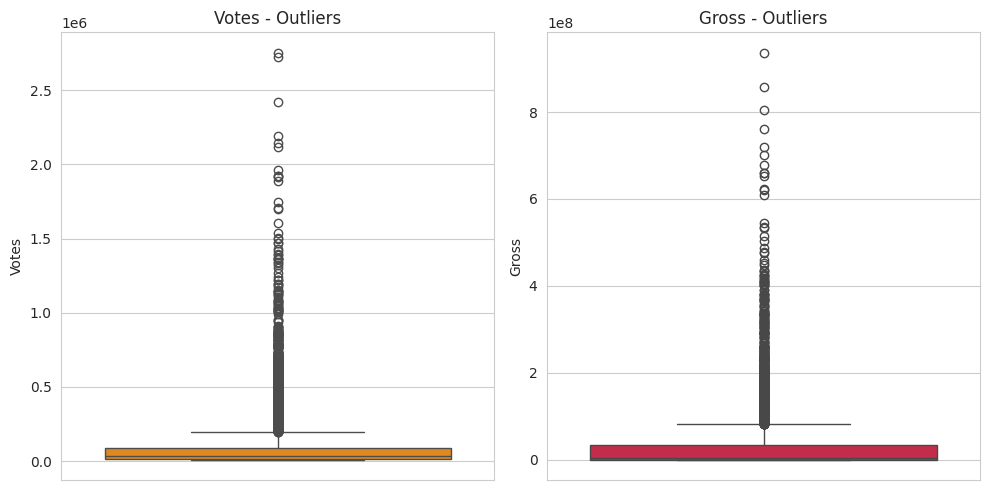

In [19]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Votes'], color='darkorange')
plt.title('Votes - Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Gross'], color='crimson')
plt.title('Gross - Outliers')

plt.tight_layout()
plt.show()


**Insight:** `Votes` and `Gross` have many outliers — a small number of blockbuster movies have extremely high votes and earnings compared to the rest. These are real values (big hit movies), not data errors, so we keep them.

In [20]:
top_5_gross = df.sort_values('Gross', ascending=False)[['Movie Name', 'Rating', 'Votes', 'Gross']].head(5)
top_5_gross


,Movie Name,Rating,Votes,Gross
887,Star Wars: Episode VII - The Force Awakens,7.8,948549,936662225
108,Avengers: Endgame,8.4,1184770,858373000
229,Spider-Man: No Way Home,8.2,802644,804747988
676,Avatar,7.9,1345064,760507625
152,Top Gun: Maverick,8.3,596202,718732821


**Insight:** These are the top 5 highest-grossing movies in the dataset — all well-known blockbusters, confirming the outliers make sense.

## Phase 9: Create a Few Useful New Columns

### 9.1 Popularity Category (Based on Votes)

In [21]:
df['Popularity'] = pd.cut(
    df['Votes'],
    bins=[0, 50000, 500000, df['Votes'].max()],
    labels=['Low', 'Medium', 'High']
)
df['Popularity'].value_counts()


Popularity
Low       6122
Medium    3575
High       302
Name: count, dtype: int64

**Insight:** We grouped movies into Low, Medium, and High popularity based on their vote count. This makes it easier to compare groups instead of working with raw numbers.

### 9.2 Average Rating by Popularity Group

In [22]:
df.groupby('Popularity')['Rating'].mean()


Popularity
Low       6.578863
Medium    6.804084
High      7.877815
Name: Rating, dtype: float64

**Insight:** More popular movies (higher votes) tend to have a slightly higher average rating.

## Phase 10: Final Summary

### Key Takeaways

- The dataset has **9,999 movies** with information like Rating, Genre, Runtime, Votes, and Gross earnings.
- Only the `Metascore` column had missing values — these were filled with the median.
- `Runtime` needed cleaning (it was text like `142 min`) and was converted to numbers.
- Most movies are rated between **7 and 8.5**, since this list only contains top-rated movies.
- **Drama** is the most common genre.
- **Votes and Gross earnings are strongly related** — popular movies tend to earn more.
- **Rating doesn't strongly depend on any single number** like runtime or votes — it likely depends more on genre, story, and direction.
- A few movies have extremely high votes/earnings (blockbusters) — these are real, not errors.

### What Could Be Done Next
- Look deeper into which directors/actors are linked to higher ratings
- Try to predict a movie's rating using genre and other features
- Analyze the movie `Plot` text for common themes or keywords


In [23]:
df.to_csv("Top_10000_Movies_IMD_cleaned_simple.csv", index=False)
print("Cleaned dataset saved!")


Cleaned dataset saved!
